# Avaliação de Modelos: MAE, RMSE e MAPE

### Módulo F1 | Previsão de Demanda na Gestão de Planos de Saúde

**Prof. Pedro** &nbsp;·&nbsp; Mestrado e Doutorado em Simulação

---

Nos notebooks anteriores treinamos muitos modelos e, em todos, apareceram três siglas: **MAE**, **RMSE** e **MAPE**. Usamos elas o tempo todo para decidir qual modelo era melhor. Nesta aula paramos de usar e passamos a **entender**.

A pergunta parece simples: _o modelo está bom?_ Ela não tem resposta única, e esse é o ponto da aula. Uma previsão que erra 10 pacientes por dia é excelente para um hospital de 500 atendimentos e péssima para um de 30. Um modelo que erra pouco quase sempre, mas erra feio uma vez por mês, pode ser melhor ou pior do que outro que erra médio todo dia, **dependendo do que custa cada tipo de erro na sua operação**.

Esta aula é a mais simples do módulo em matemática e a mais importante em consequência. Errar a escolha da métrica significa escolher o modelo errado com toda a confiança do mundo.

**Ao final desta aula você será capaz de:**

1. Calcular MAE, RMSE e MAPE **na mão** e explicar cada um em uma frase.
2. Saber por que o RMSE é sempre maior ou igual ao MAE, e o que a diferença entre os dois revela.
3. Reconhecer quando a métrica escolhida **muda qual modelo vence**.
4. Identificar os dois defeitos do MAPE e saber quando usar WMAPE ou MASE no lugar.
5. Avaliar **fora da amostra** do jeito certo, e reconhecer por que a divisão aleatória mente em séries temporais.
6. Aplicar a validação **walk-forward** e entender por que um único holdout pode enganar.
7. Adaptar a métrica quando **faltar e sobrar custam diferente**, que é a regra na operação de saúde.

Vamos usar exemplos pequenos, com números que você pode conferir na calculadora, e só no fim aplicar tudo a uma série real.


## 0. Preparação do ambiente


In [1]:
import sys, subprocess

def _garantir(pacotes):
    for nome in pacotes:
        try:
            __import__(nome)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", nome])

_garantir(["numpy", "pandas", "matplotlib", "sklearn", "ipywidgets"])

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

SEMENTE = 11
print("Ambiente pronto.")

Ambiente pronto.


## O problema: como resumir os erros em um número?

Vamos começar com uma semana de operação de uma central de atendimento. Temos o volume **real** de ligações de cada dia e o que o modelo **previu**. Sete dias, sete erros. A pergunta é: como transformar esses sete números em **um** número que diga se o modelo é bom?

A primeira ideia que ocorre a todo mundo é tirar a **média dos erros**. Vamos ver o que acontece.


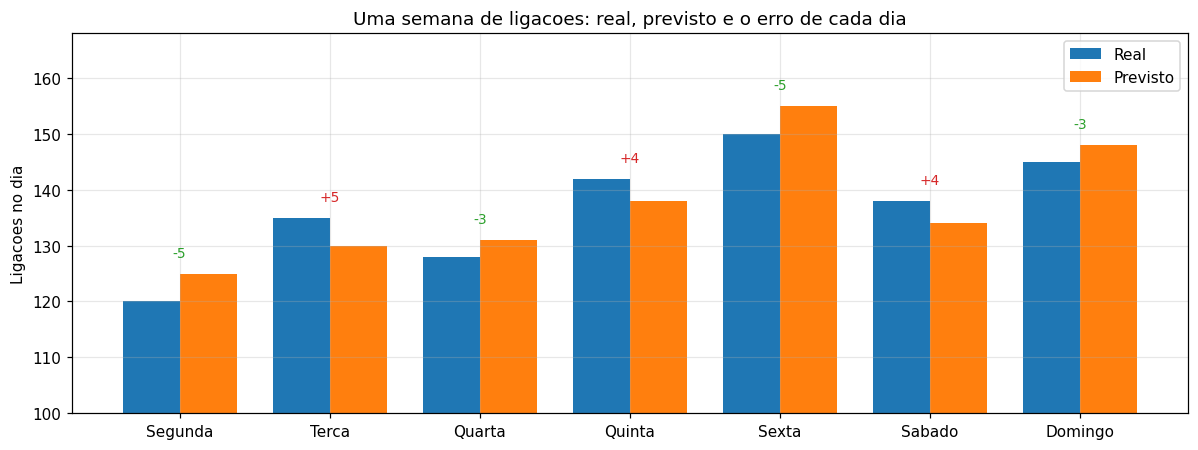

Soma dos erros  : -3
MEDIA dos erros : -0.429   <-  parece quase perfeito, e nao e

    dia  real  previsto  erro (real - previsto)  erro absoluto  erro ao quadrado  erro percentual (%)
Segunda   120       125                      -5              5                25                 4.17
  Terca   135       130                       5              5                25                 3.70
 Quarta   128       131                      -3              3                 9                 2.34
 Quinta   142       138                       4              4                16                 2.82
  Sexta   150       155                      -5              5                25                 3.33
 Sabado   138       134                       4              4                16                 2.90
Domingo   145       148                      -3              3                 9                 2.07


In [2]:
dias = ["Segunda", "Terca", "Quarta", "Quinta", "Sexta", "Sabado", "Domingo"]
real = np.array([120, 135, 128, 142, 150, 138, 145], dtype=float)
previsto = np.array([125, 130, 131, 138, 155, 134, 148], dtype=float)

erro = real - previsto          # positivo = o modelo previu MENOS do que aconteceu

tabela = pd.DataFrame({
    "dia": dias,
    "real": real.astype(int),
    "previsto": previsto.astype(int),
    "erro (real - previsto)": erro.astype(int),
    "erro absoluto": np.abs(erro).astype(int),
    "erro ao quadrado": (erro ** 2).astype(int),
    "erro percentual (%)": (100 * np.abs(erro) / real).round(2),
})

fig, ax = plt.subplots(figsize=(11, 4.2))
largura = 0.38
posicoes = np.arange(7)
ax.bar(posicoes - largura/2, real, largura, color="#1f77b4", label="Real")
ax.bar(posicoes + largura/2, previsto, largura, color="#ff7f0e", label="Previsto")
for i, e in enumerate(erro):
    ax.annotate(f"{e:+.0f}", (i, max(real[i], previsto[i]) + 3), ha="center", fontsize=9,
                color="#d62728" if e > 0 else "#2ca02c")
ax.set_ylim(100, 168)
ax.set_xticks(posicoes); ax.set_xticklabels(dias)
ax.set_title("Uma semana de ligacoes: real, previsto e o erro de cada dia")
ax.set_ylabel("Ligacoes no dia"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Soma dos erros  : {erro.sum():+.0f}")
print(f"MEDIA dos erros : {erro.mean():+.3f}   <-  parece quase perfeito, e nao e")
print()
print(tabela.to_string(index=False))

> **Lendo o resultado.** A média simples dos erros deu **-0,43 ligação**. Se olhássemos só esse número, concluiríamos que o modelo é praticamente perfeito.
>
> E ele não é. Olhe a coluna dos erros: **-5, +5, -3, +4, -5, +4, -3**. O modelo errou **todos os dias**, entre 3 e 5 ligações. O que aconteceu é que os erros para mais **cancelaram** os erros para menos, e a média escondeu o problema por completo.
>
> Essa é a razão de existirem MAE, RMSE e MAPE. As três resolvem o mesmo problema, **impedir que erros de sinais opostos se cancelem**, e cada uma resolve de um jeito:
>
> | Métrica  | Como remove o sinal    | O que isso significa na prática                     |
> | -------- | ---------------------- | --------------------------------------------------- |
> | **MAE**  | valor **absoluto**     | trata todos os erros com o mesmo peso               |
> | **RMSE** | eleva ao **quadrado**  | pune erros grandes muito mais do que erros pequenos |
> | **MAPE** | erro em **percentual** | mede o erro em proporção ao tamanho do valor real   |
>
> Uma observação que vale guardar: a média dos erros **não é inútil**, ela só não serve para medir precisão. Ela mede outra coisa, o **viés**: se der bem diferente de zero, o modelo está sistematicamente otimista ou pessimista. Aqui, -0,43 em uma operação de 137 ligações por dia indica um modelo sem viés relevante. Precisão e viés são duas perguntas diferentes, e cada uma tem o seu número.


## MAE: o erro médio absoluto

$$ \text{MAE} = \frac{1}{n} \sum\_{i=1}^{n} \left| y_i - \hat{y}\_i \right| $$

Em palavras: **tire o sinal de cada erro e faça a média**. É a métrica mais fácil de explicar para quem não é da área, porque ela sai na **mesma unidade do problema**. Se o MAE é 4,1 ligações, a frase que vai para a reunião é: _"em média, erramos 4 ligações por dia"_. Qualquer pessoa entende, e ninguém precisa saber o que é um desvio-padrão.

## RMSE: a raiz do erro quadrático médio

$$ \text{RMSE} = \sqrt{ \frac{1}{n} \sum\_{i=1}^{n} \left( y_i - \hat{y}\_i \right)^2 } $$

Aqui há três passos: eleva ao quadrado (o que remove o sinal **e** amplia os erros grandes), tira a média, e depois tira a raiz para voltar à unidade original. O quadrado é o coração da coisa: um erro de 10 pesa **quatro vezes** mais do que dois erros de 5, porque $10^2 = 100$ enquanto $2 \times 5^2 = 50$.

## MAPE: o erro percentual absoluto médio

$$ \text{MAPE} = \frac{100}{n} \sum\_{i=1}^{n} \left| \frac{y_i - \hat{y}\_i}{y_i} \right| $$

Divide cada erro pelo valor real, o que transforma tudo em **percentual**. A vantagem é a comparabilidade: 5% de erro significa a mesma coisa em um PA de 30 e em um de 500 atendimentos. É a métrica que a literatura usa para comparar estudos de hospitais diferentes.

Vamos calcular as três na mão e conferir com a biblioteca.


In [3]:
n = len(erro)

mae = np.sum(np.abs(erro)) / n
rmse = np.sqrt(np.sum(erro ** 2) / n)
mape = 100 * np.sum(np.abs(erro / real)) / n

print("CALCULANDO NA MAO, passo a passo\n")
print(f"  soma dos erros ABSOLUTOS   = {np.sum(np.abs(erro)):.0f}")
print(f"  MAE  = {np.sum(np.abs(erro)):.0f} / {n} = {mae:.4f} ligacoes\n")
print(f"  soma dos erros AO QUADRADO = {np.sum(erro ** 2):.0f}")
print(f"  RMSE = raiz({np.sum(erro ** 2):.0f} / {n}) = raiz({np.sum(erro ** 2) / n:.4f}) = {rmse:.4f} ligacoes\n")
print(f"  soma dos erros PERCENTUAIS = {np.sum(np.abs(erro / real)):.6f}")
print(f"  MAPE = 100 x {np.sum(np.abs(erro / real)):.6f} / {n} = {mape:.4f}%\n")

# Conferindo com o scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
print("CONFERINDO com o scikit-learn")
print(f"  MAE  = {mean_absolute_error(real, previsto):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(real, previsto)):.4f}")
print(f"  MAPE = {100 * mean_absolute_percentage_error(real, previsto):.4f}%")


def metricas(y_real, y_previsto):
    """As tres metricas de uma vez. Vamos reusar esta funcao no resto do notebook."""
    y_real = np.asarray(y_real, dtype=float)
    y_previsto = np.asarray(y_previsto, dtype=float)
    e = y_real - y_previsto
    return (np.mean(np.abs(e)),
            np.sqrt(np.mean(e ** 2)),
            100 * np.mean(np.abs(e / y_real)))

CALCULANDO NA MAO, passo a passo

  soma dos erros ABSOLUTOS   = 29
  MAE  = 29 / 7 = 4.1429 ligacoes

  soma dos erros AO QUADRADO = 125
  RMSE = raiz(125 / 7) = raiz(17.8571) = 4.2258 ligacoes

  soma dos erros PERCENTUAIS = 0.213319
  MAPE = 100 x 0.213319 / 7 = 3.0474%

CONFERINDO com o scikit-learn
  MAE  = 4.1429
  RMSE = 4.2258
  MAPE = 3.0474%


> **Lendo o resultado.** Os três números da nossa semana:
>
> - **MAE = 4,14 ligações.** Erramos, em média, pouco mais de 4 ligações por dia.
> - **RMSE = 4,23 ligações.** Ligeiramente maior que o MAE.
> - **MAPE = 3,05%.** Erramos cerca de 3% do volume.
>
> E o mais importante: as contas feitas na mão batem **exatamente** com o `scikit-learn`. Não há nada de misterioso dentro dessas funções, apenas as três linhas de aritmética que acabamos de escrever.
>
> Repare que o **RMSE (4,23) é maior que o MAE (4,14)**, e isso não é coincidência: **o RMSE é sempre maior ou igual ao MAE**, para qualquer conjunto de erros. Eles só ficam iguais quando **todos os erros têm exatamente o mesmo tamanho**. Aqui os erros são 3, 4 e 5, bem parecidos entre si, e por isso as duas métricas quase coincidem.
>
> Isso dá um diagnóstico gratuito e muito útil:
>
> $$ \frac{\text{RMSE}}{\text{MAE}} \approx 1 \;\Rightarrow\; \text{erros parecidos entre si} \qquad\qquad \frac{\text{RMSE}}{\text{MAE}} \text{ alto} \;\Rightarrow\; \text{existem erros grandes isolados} $$
>
> Na nossa semana a razão é **4,23 / 4,14 = 1,02**, ou seja, nenhum erro isolado se destaca. Vamos ver o que acontece quando um dia sai da curva.


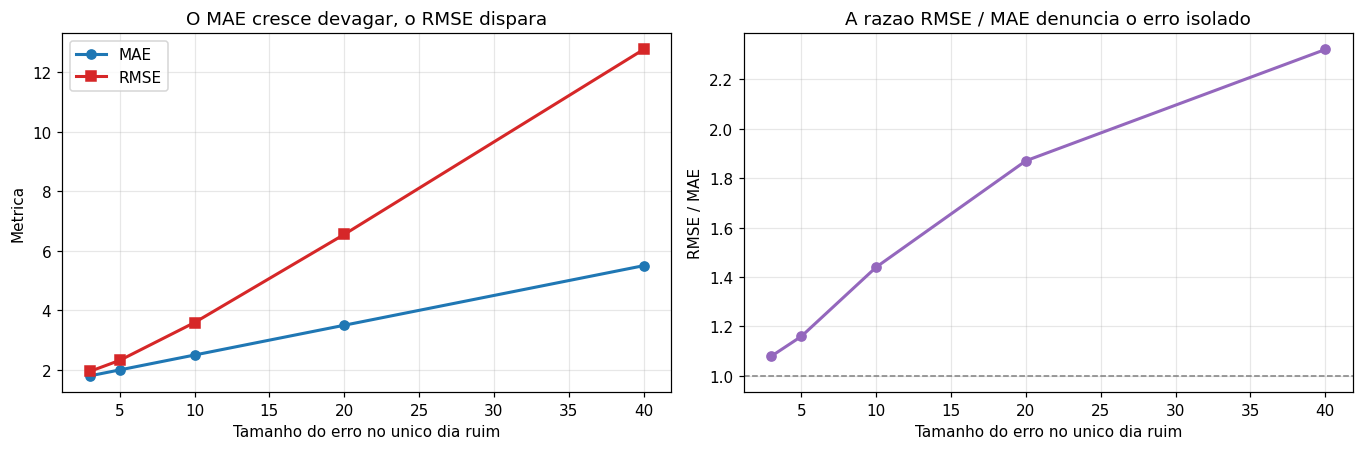

,maior erro do periodo,MAE,RMSE,RMSE / MAE
0,3,1.8,1.95,1.08
1,5,2.0,2.32,1.16
2,10,2.5,3.59,1.44
3,20,3.5,6.55,1.87
4,40,5.5,12.76,2.32


In [4]:
# Um conjunto de 10 erros pequenos e bem comportados, e o que acontece quando UM cresce
erros_base = np.array([2, -3, 1, -2, 3, -1, 2, -2, 1, -1], dtype=float)

linhas, tamanhos = [], [3, 5, 10, 20, 40]
for tamanho in tamanhos:
    e = erros_base.copy()
    e[4] = tamanho                                   # o quinto dia passa a ser o dia ruim
    m, r = np.mean(np.abs(e)), np.sqrt(np.mean(e ** 2))
    linhas.append({"maior erro do periodo": tamanho, "MAE": round(m, 2),
                   "RMSE": round(r, 2), "RMSE / MAE": round(r / m, 2)})
comparacao = pd.DataFrame(linhas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax1.plot(comparacao["maior erro do periodo"], comparacao["MAE"], marker="o", lw=2,
         color="#1f77b4", label="MAE")
ax1.plot(comparacao["maior erro do periodo"], comparacao["RMSE"], marker="s", lw=2,
         color="#d62728", label="RMSE")
ax1.set_title("O MAE cresce devagar, o RMSE dispara")
ax1.set_xlabel("Tamanho do erro no unico dia ruim"); ax1.set_ylabel("Metrica"); ax1.legend()

ax2.plot(comparacao["maior erro do periodo"], comparacao["RMSE / MAE"], marker="o", lw=2, color="#9467bd")
ax2.axhline(1, color="gray", ls="--", lw=1)
ax2.set_title("A razao RMSE / MAE denuncia o erro isolado")
ax2.set_xlabel("Tamanho do erro no unico dia ruim"); ax2.set_ylabel("RMSE / MAE")
plt.tight_layout(); plt.show()

comparacao

> **Lendo o gráfico.** Nove dos dez erros ficaram **exatamente iguais** o tempo todo. Só um dia mudou, e veja o efeito:
>
> - Quando o dia ruim erra **3**, MAE = 1,80 e RMSE = 1,95. Praticamente iguais.
> - Quando o dia ruim erra **40**, MAE = 5,50 e RMSE = **12,76**. O MAE triplicou; o RMSE ficou **seis vezes maior**.
>
> A razão RMSE/MAE saiu de 1,08 para **2,32**, e é isso que a torna um instrumento de diagnóstico: sempre que ela estiver muito acima de 1, procure **poucos dias com erro muito grande**, porque eles existem.
>
> Qual das duas está certa? **As duas.** Elas respondem a perguntas diferentes:
>
> - O **MAE** responde: _"quanto eu erro em um dia típico?"_
> - O **RMSE** responde: _"quão ruim é quando dá errado?"_
>
> E a escolha entre elas não é estatística, é **operacional**. Se um dia com 40 pacientes a mais do que o previsto significa fila, ambulância desviada e paciente esperando no corredor, aquele único dia importa muito mais do que a soma de todos os dias tranquilos, e a métrica certa é o RMSE. Se o que interessa é o custo acumulado no mês, em que sobrar num dia compensa faltar no outro, a métrica certa é o MAE.


### O caso em que a métrica escolhida muda o vencedor

Até aqui, MAE e RMSE apontaram na mesma direção. Agora vem o momento mais importante da aula: uma situação, muito comum na prática, em que **as duas métricas elegem modelos diferentes**.

Imagine dois modelos candidatos para prever chegadas ao pronto atendimento, avaliados na mesma semana:

- **Modelo A, o preciso e frágil.** Acerta quase na mosca seis dias, errando 1 paciente por dia. No sétimo, não enxerga um evento e erra 20.
- **Modelo B, o mediano e constante.** Erra 5 pacientes todos os dias, sem exceção e sem surpresa.

Qual dos dois você levaria para produção?


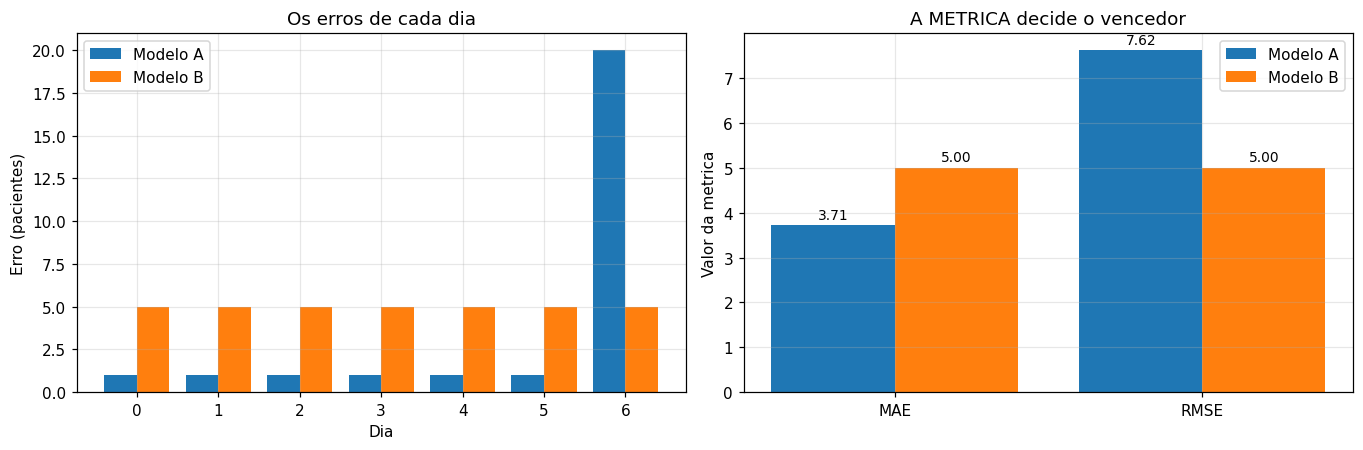

,modelo,MAE,RMSE,maior erro,vence no MAE,vence no RMSE
0,"A (preciso, mas falha feio um dia)",3.714,7.616,20,True,False
1,"B (erra medio, mas nunca falha feio)",5.000,5.000,5,False,True


In [5]:
erros_A = np.array([1, 1, 1, 1, 1, 1, 20], dtype=float)     # quase perfeito, com um desastre
erros_B = np.array([5, 5, 5, 5, 5, 5, 5], dtype=float)      # medianamente errado todo dia

placar = pd.DataFrame([
    {"modelo": "A (preciso, mas falha feio um dia)",
     "MAE": round(np.mean(np.abs(erros_A)), 3), "RMSE": round(np.sqrt(np.mean(erros_A ** 2)), 3),
     "maior erro": int(erros_A.max())},
    {"modelo": "B (erra medio, mas nunca falha feio)",
     "MAE": round(np.mean(np.abs(erros_B)), 3), "RMSE": round(np.sqrt(np.mean(erros_B ** 2)), 3),
     "maior erro": int(erros_B.max())},
])
placar["vence no MAE"] = placar.MAE == placar.MAE.min()
placar["vence no RMSE"] = placar.RMSE == placar.RMSE.min()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))
posicoes = np.arange(7)
ax1.bar(posicoes - 0.2, erros_A, 0.4, color="#1f77b4", label="Modelo A")
ax1.bar(posicoes + 0.2, erros_B, 0.4, color="#ff7f0e", label="Modelo B")
ax1.set_title("Os erros de cada dia"); ax1.set_xlabel("Dia"); ax1.set_ylabel("Erro (pacientes)")
ax1.legend()

metricas_nomes = ["MAE", "RMSE"]
valores_A = [np.mean(np.abs(erros_A)), np.sqrt(np.mean(erros_A ** 2))]
valores_B = [np.mean(np.abs(erros_B)), np.sqrt(np.mean(erros_B ** 2))]
ax2.bar(np.arange(2) - 0.2, valores_A, 0.4, color="#1f77b4", label="Modelo A")
ax2.bar(np.arange(2) + 0.2, valores_B, 0.4, color="#ff7f0e", label="Modelo B")
ax2.set_xticks(range(2)); ax2.set_xticklabels(metricas_nomes)
ax2.set_title("A METRICA decide o vencedor")
ax2.set_ylabel("Valor da metrica"); ax2.legend()
for i, (a, b) in enumerate(zip(valores_A, valores_B)):
    ax2.annotate(f"{a:.2f}", (i - 0.2, a + 0.15), ha="center", fontsize=9)
    ax2.annotate(f"{b:.2f}", (i + 0.2, b + 0.15), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

placar

> **Lendo o resultado.** Os números:
>
> | Modelo | MAE      | RMSE     |
> | ------ | -------- | -------- |
> | **A**  | **3,71** | 7,62     |
> | **B**  | 5,00     | **5,00** |
>
> **O modelo A vence no MAE. O modelo B vence no RMSE.** Mesmos dados, mesma semana, dois vencedores diferentes. Não existe erro de cálculo aqui, e nem uma métrica melhor que a outra: existem duas perguntas diferentes sendo respondidas.
>
> A decisão é do negócio, e ela tem uma pergunta guia: **o custo do erro é proporcional ao tamanho dele, ou cresce mais rápido?**
>
> - Se **um dia com 20 pacientes a mais** significa fila de espera, desvio de ambulância e risco assistencial, então aquele dia sozinho custa mais do que os seis dias tranquilos juntos. O custo **não** é proporcional, e a métrica certa é o **RMSE**. Escolha o modelo B.
> - Se o que importa é o **total de horas de atendente contratadas no mês**, em que sobrar num dia compensa faltar no outro, o custo **é** proporcional, e a métrica certa é o **MAE**. Escolha o modelo A.
>
> Guarde esta como a regra prática mais útil desta aula: **escolha a métrica antes de treinar os modelos**, e escolha conversando com quem sofre o erro. Métrica definida depois que os resultados chegam vira justificativa para o modelo de que já gostávamos.


## MAPE: útil, popular, e com dois defeitos sérios

O MAPE é a métrica preferida em relatórios de gestão, e por um bom motivo: **"erramos 5%"** é uma frase que todo mundo entende, sem precisar saber se a operação tem 30 ou 3.000 atendimentos. É também o que permite comparar o seu modelo com a literatura. A apostila menciona, na Seção 12.2, que os estudos revisados relatam **MAPE entre 8% e 15%** para previsão de chegadas hospitalares, e é contra esse patamar que um resultado novo deve ser lido.

Mas ele tem dois defeitos que você precisa conhecer antes de colocá-lo em um relatório.

**Defeito 1: divide por zero.** Se o valor real de uma hora foi **zero** chegadas, a divisão explode. E isso não é um caso de laboratório: às 4h da manhã, um pronto atendimento pequeno tem zeros com frequência.

**Defeito 2: é assimétrico.** O MAPE **pune mais quem prevê a mais do que quem prevê a menos**. Prever a metade do real dá um erro de 50%; prever o dobro dá 100%. Como consequência, um processo automático que escolha modelo por MAPE tende a preferir modelos **sistematicamente conservadores**, que subestimam a demanda. Em saúde, subestimar demanda é exatamente o erro que não se quer incentivar.


In [6]:
print("DEFEITO 1: divisao por zero\n")
real_madrugada = np.array([3, 1, 0, 2, 0, 4], dtype=float)
prev_madrugada = np.array([2, 2, 1, 2, 1, 3], dtype=float)
with np.errstate(divide="ignore", invalid="ignore"):
    percentuais = np.abs((real_madrugada - prev_madrugada) / real_madrugada)
print(pd.DataFrame({"real": real_madrugada.astype(int), "previsto": prev_madrugada.astype(int),
                    "erro % ": np.round(percentuais * 100, 1)}).to_string(index=False))
print(f"\n  MAPE = {100 * np.mean(percentuais):.1f}  <- infinito, a metrica quebrou")
print(f"  MAE  = {np.mean(np.abs(real_madrugada - prev_madrugada)):.2f}  <- continua funcionando\n")

print("\nDEFEITO 2: assimetria (o real e sempre 100)\n")
casos = pd.DataFrame([
    {"situacao": "Previu a METADE (50)", "real": 100, "previsto": 50,
     "erro absoluto": 50, "MAPE": "50%"},
    {"situacao": "Previu o DOBRO (200)", "real": 100, "previsto": 200,
     "erro absoluto": 100, "MAPE": "100%"},
    {"situacao": "Previu ZERO", "real": 100, "previsto": 0,
     "erro absoluto": 100, "MAPE": "100%  <- o teto para quem subestima"},
    {"situacao": "Previu o TRIPLO (300)", "real": 100, "previsto": 300,
     "erro absoluto": 200, "MAPE": "200%  <- nao existe teto para quem superestima"},
])
print(casos.to_string(index=False))
print("\n  Quem subestima nunca passa de 100% de MAPE. Quem superestima nao tem limite.")
print("  Resultado: escolher modelo por MAPE empurra a previsao para BAIXO.")

DEFEITO 1: divisao por zero

 real  previsto  erro % 
    3         2     33.3
    1         2    100.0
    0         1      inf
    2         2      0.0
    0         1      inf
    4         3     25.0

  MAPE = inf  <- infinito, a metrica quebrou
  MAE  = 0.83  <- continua funcionando


DEFEITO 2: assimetria (o real e sempre 100)

             situacao  real  previsto  erro absoluto                                           MAPE
 Previu a METADE (50)   100        50             50                                            50%
 Previu o DOBRO (200)   100       200            100                                           100%
          Previu ZERO   100         0            100            100%  <- o teto para quem subestima
Previu o TRIPLO (300)   100       300            200 200%  <- nao existe teto para quem superestima

  Quem subestima nunca passa de 100% de MAPE. Quem superestima nao tem limite.
  Resultado: escolher modelo por MAPE empurra a previsao para BAIXO.


> **Lendo o resultado.** Os dois defeitos, na prática:
>
> **Divisão por zero.** Naquelas seis horas de madrugada, duas tiveram zero chegadas. O MAPE virou **infinito** e deixou de existir como número, enquanto o MAE seguiu funcionando normalmente e informou **0,83 paciente** de erro médio. Note que a saída mais comum, "vou só ignorar as horas com zero", é pior do que parece: você passa a avaliar o modelo **apenas nas horas movimentadas**, e o número que sai não representa a operação inteira.
>
> **Assimetria.** A tabela mostra o teto invisível: **quem subestima nunca ultrapassa 100% de MAPE**, porque o pior caso é prever zero. Quem superestima não tem limite nenhum, e prever o triplo já custa 200%. Um processo de seleção automática que otimize MAPE vai, sistematicamente, preferir o modelo mais tímido.
>
> Isso importa muito em saúde. Se o custo de subdimensionar uma escala é maior do que o de superdimensionar, e em pronto atendimento normalmente é, então **usar MAPE como critério de escolha empurra a decisão exatamente para o lado errado**.


### Duas alternativas que resolvem os defeitos do MAPE

**WMAPE** (_Weighted MAPE_), também chamado de MAD/Mean ratio. Em vez de dividir cada erro pelo seu próprio valor real, ele divide a **soma dos erros** pela **soma dos valores reais**:

$$ \text{WMAPE} = \frac{\sum_i |y_i - \hat{y}\_i|}{\sum_i y_i} \times 100 $$

Como a divisão acontece uma vez só, no fim, **um zero isolado não quebra nada**, e horas de baixo volume deixam de dominar o resultado. É a métrica percentual que eu recomendo como padrão em séries com valores pequenos ou com zeros.

**MASE** (_Mean Absolute Scaled Error_). Divide o MAE do modelo pelo MAE de uma **previsão ingênua** (tipicamente repetir o valor do período sazonal anterior):

$$ \text{MASE} = \frac{\text{MAE}_{\text{modelo}}}{\text{MAE}_{\text{ingênuo}}} $$

A leitura é imediata: **MASE menor que 1 significa que o modelo é melhor do que a regra boba**; maior que 1 significa que todo o trabalho de modelagem não superou "repita o que aconteceu na semana passada". É a métrica mais honesta para responder à pergunta que a diretoria realmente faz, que é _"isso aqui compensa?"_.


In [7]:
def wmape(y_real, y_previsto):
    y_real = np.asarray(y_real, float); y_previsto = np.asarray(y_previsto, float)
    return 100 * np.sum(np.abs(y_real - y_previsto)) / np.sum(y_real)

def mase(y_real, y_previsto, y_ingenuo):
    y_real = np.asarray(y_real, float)
    erro_modelo = np.mean(np.abs(y_real - np.asarray(y_previsto, float)))
    erro_ingenuo = np.mean(np.abs(y_real - np.asarray(y_ingenuo, float)))
    return erro_modelo / erro_ingenuo

# Na semana do inicio do notebook, a previsao ingenua e repetir o dia anterior
ingenuo = np.concatenate([[real[0]], real[:-1]])

print("Na nossa semana de 7 dias:")
print(f"  MAE   = {metricas(real, previsto)[0]:.3f} ligacoes")
print(f"  RMSE  = {metricas(real, previsto)[1]:.3f} ligacoes")
print(f"  MAPE  = {metricas(real, previsto)[2]:.3f}%")
print(f"  WMAPE = {wmape(real, previsto):.3f}%")
print(f"  MASE  = {mase(real, previsto, ingenuo):.3f}   "
      f"(o ingenuo erra {np.mean(np.abs(real - ingenuo)):.2f}, o modelo erra {metricas(real, previsto)[0]:.2f})")
print()
print("E na madrugada com zeros, onde o MAPE quebrou:")
print(f"  MAPE  = infinito")
print(f"  WMAPE = {wmape(real_madrugada, prev_madrugada):.1f}%   <- continua funcionando")

Na nossa semana de 7 dias:
  MAE   = 4.143 ligacoes
  RMSE  = 4.226 ligacoes
  MAPE  = 3.047%
  WMAPE = 3.027%
  MASE  = 0.460   (o ingenuo erra 9.00, o modelo erra 4.14)

E na madrugada com zeros, onde o MAPE quebrou:
  MAPE  = infinito
  WMAPE = 50.0%   <- continua funcionando


> **Lendo o resultado.** Na nossa semana, MAPE (3,05%) e WMAPE (3,03%) ficam praticamente iguais, porque os sete dias têm volumes parecidos. **A diferença entre os dois só aparece quando os valores variam muito**, e é exatamente aí que o MAPE falha e o WMAPE segura, como mostra a madrugada: o MAPE virou infinito e o WMAPE devolveu **50,0%**, um número alto mas verdadeiro e utilizável.
>
> O **MASE de 0,46** é a informação mais direta de todas: repetir o dia anterior erraria **9,00 ligações** e o nosso modelo erra **4,14**. Traduzido para a reunião: _"o modelo reduz o erro pela metade em relação a não fazer nada"_. Essa é a frase que justifica o projeto, e nenhuma das outras métricas a produz sozinha.
>
> **Resumo de qual usar, e quando:**
>
> | Métrica   | Use quando                                                 | Cuidado                                         |
> | --------- | ---------------------------------------------------------- | ----------------------------------------------- |
> | **MAE**   | o custo do erro é proporcional ao tamanho dele             | não destaca os dias de desastre                 |
> | **RMSE**  | erros grandes são desproporcionalmente caros               | um único outlier pode dominar o resultado       |
> | **MAPE**  | comparar séries de escalas diferentes, ou com a literatura | quebra com zeros e é assimétrico                |
> | **WMAPE** | quer percentual em série com valores pequenos ou zeros     | não é a métrica que a literatura reporta        |
> | **MASE**  | responder se o modelo compensa frente à regra simples      | depende de qual ingênuo você escolheu como base |
>
> A recomendação prática: **reporte MAE e RMSE sempre juntos** (a razão entre eles já conta uma história), acrescente **WMAPE ou MAPE** para a comunicação com a gestão, e use **MASE** uma vez, no começo do projeto, para justificar que ele existe.


## 12.2 Onde medir: a avaliação fora da amostra

Já sabemos **como** medir. Falta a parte que decide se a medição vale alguma coisa: **em quais dados medir**.

A regra é uma só, e é absoluta: **nunca avalie o modelo nos dados em que ele foi treinado**. Um modelo suficientemente flexível decora o histórico e devolve erro quase zero no treino, sem ter aprendido nada que sirva para amanhã. Já vimos isso acontecer no notebook de árvores, onde o erro de treino chegou a **0,00** enquanto o erro real subia.

Vamos trabalhar agora com dois anos de uma série diária de ligações e quatro candidatos, todos simples de propósito, porque o assunto aqui é a **avaliação**, não a modelagem.


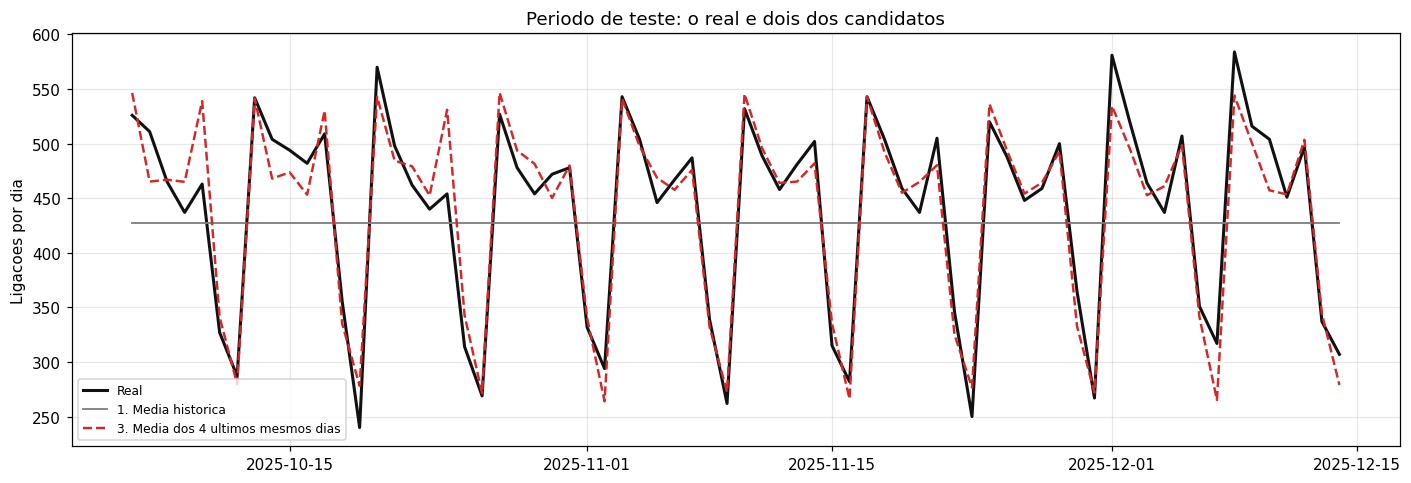

Treino: 01/01/2024 a 06/08/2025 (584 dias)
Teste : 07/08/2025 a 30/12/2025 (146 dias)



,modelo,MAE,RMSE,MAPE (%),RMSE/MAE,MASE
0,1. Media historica,83.05,94.56,21.13,1.14,3.42
1,2. Mesmo dia da semana passada,24.31,34.71,5.82,1.43,1.00
2,3. Media dos 4 ultimos mesmos dias,19.62,27.32,4.59,1.39,0.81
3,4. Nivel recente x perfil semanal,20.29,27.54,4.71,1.36,0.83


In [8]:
def gerar_serie(dias=730, semente=SEMENTE):
    """Serie diaria de ligacoes: nivel com tendencia, ciclo semanal, sazonalidade anual e picos."""
    g = np.random.default_rng(semente)
    datas = pd.date_range("2024-01-01", periods=dias, freq="D")
    dia_semana = datas.dayofweek.to_numpy()
    t = np.arange(dias)
    perfil_semanal = np.array([1.18, 1.06, 1.00, 0.99, 1.04, 0.72, 0.58])
    nivel = 420 + 0.10 * t + 22 * np.sin(2 * np.pi * (t - 30) / 365)
    picos = np.zeros(dias)
    for d in range(dias):
        if g.random() < 0.02:                       # 2% dos dias tem um evento inesperado
            picos[d] += g.uniform(60, 160)
    valores = np.clip(np.round(nivel * perfil_semanal[dia_semana] + picos + g.normal(0, 18, dias)), 0, None)
    return pd.Series(valores, index=datas, name="ligacoes")


serie = gerar_serie()
n = len(serie)
corte = int(0.8 * n)
treino, teste = serie.iloc[:corte], serie.iloc[corte:]

# Quatro candidatos simples
prev_media = np.full(len(teste), treino.mean())
prev_semana_passada = serie.shift(7).iloc[corte:].values
media_4_semanas = serie.groupby(serie.index.dayofweek).transform(lambda x: x.shift(1).rolling(4).mean())
prev_media4 = media_4_semanas.iloc[corte:].values
perfil = treino.groupby(treino.index.dayofweek).mean() / treino.mean()
prev_nivel_perfil = treino.iloc[-28:].mean() * perfil.reindex(teste.index.dayofweek).values

candidatos = {
    "1. Media historica": prev_media,
    "2. Mesmo dia da semana passada": prev_semana_passada,
    "3. Media dos 4 ultimos mesmos dias": prev_media4,
    "4. Nivel recente x perfil semanal": prev_nivel_perfil,
}

placar = []
for nome, p in candidatos.items():
    m, r, mp = metricas(teste.values, p)
    placar.append({"modelo": nome, "MAE": round(m, 2), "RMSE": round(r, 2),
                   "MAPE (%)": round(mp, 2), "RMSE/MAE": round(r / m, 2),
                   "MASE": round(mase(teste.values, p, prev_semana_passada), 2)})
placar = pd.DataFrame(placar)

fig, ax = plt.subplots(figsize=(13, 4.5))
janela = slice(60, 130)
ax.plot(teste.index[janela], teste.values[janela], color="#111111", lw=2, label="Real")
ax.plot(teste.index[janela], prev_media[janela], color="#7f7f7f", lw=1.2, label="1. Media historica")
ax.plot(teste.index[janela], prev_media4[janela], color="#d62728", lw=1.6, ls="--",
        label="3. Media dos 4 ultimos mesmos dias")
ax.set_title("Periodo de teste: o real e dois dos candidatos")
ax.set_ylabel("Ligacoes por dia"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Treino: {treino.index.min():%d/%m/%Y} a {treino.index.max():%d/%m/%Y} ({len(treino)} dias)")
print(f"Teste : {teste.index.min():%d/%m/%Y} a {teste.index.max():%d/%m/%Y} ({len(teste)} dias)\n")
placar

> **Lendo a tabela.** Os quatro candidatos, avaliados nos mesmos 146 dias de teste:
>
> - A **média histórica** erra **83 ligações por dia** (MAPE de 21%). Ela ignora o ciclo semanal, e o gráfico mostra por quê: é uma linha reta atravessando uma série que sobe e desce toda semana.
> - **Repetir o mesmo dia da semana passada** derruba o erro para **24,3** (MAPE 5,8%). Só de respeitar o calendário, o erro caiu para menos de um terço.
> - A **média dos 4 últimos mesmos dias** chega a **19,6** (MAPE 4,6%) e é a melhor de todas. Ela faz a mesma coisa que a anterior, mas tira a média de quatro semanas e com isso cancela parte do ruído.
> - **Nível recente vezes perfil semanal** fica em **20,3**, tecnicamente empatada com a anterior.
>
> Três leituras importantes:
>
> **A coluna RMSE/MAE está em torno de 1,4 em todos.** Isso denuncia os dias de pico que embutimos na série: existem poucos dias com erro bem maior que o típico, e nenhum desses modelos os prevê, porque eles são eventos genuinamente imprevisíveis.
>
> **A coluna MASE** compara tudo com "repetir a semana passada". O modelo 3 tem MASE de **0,81**, ou seja, erra 19% menos do que a regra ingênua. É um ganho real, e também é um ganho **modesto**, o que serve de calibração de expectativa antes de alguém prometer revolução.
>
> **E a lição de fundo:** os quatro candidatos aqui são regras de três linhas, sem nenhum aprendizado de máquina, e o melhor deles já chega a 4,6% de MAPE. Antes de propor um modelo sofisticado, meça o quanto a regra simples já resolve. Boa parte dos projetos de previsão que fracassam são projetos que nunca compararam com a alternativa boba.


### O erro que mais engana: dividir os dados de forma aleatória

Em problemas comuns de aprendizado de máquina, o padrão é embaralhar as linhas e separar 80% para treino e 20% para teste. Em **séries temporais isso está errado**, e o resultado é sempre otimista.

O motivo é simples de enxergar: ao sortear, o dia 15 de março cai no treino e o dia 16 cai no teste. O modelo aprende com o dia 15 e é avaliado no 16, que é o vizinho e se parece muito com ele. Em produção nada disso acontece: você treina com **todo o passado** e prevê um futuro que **ninguém viu**.

Vamos medir o tamanho da mentira.


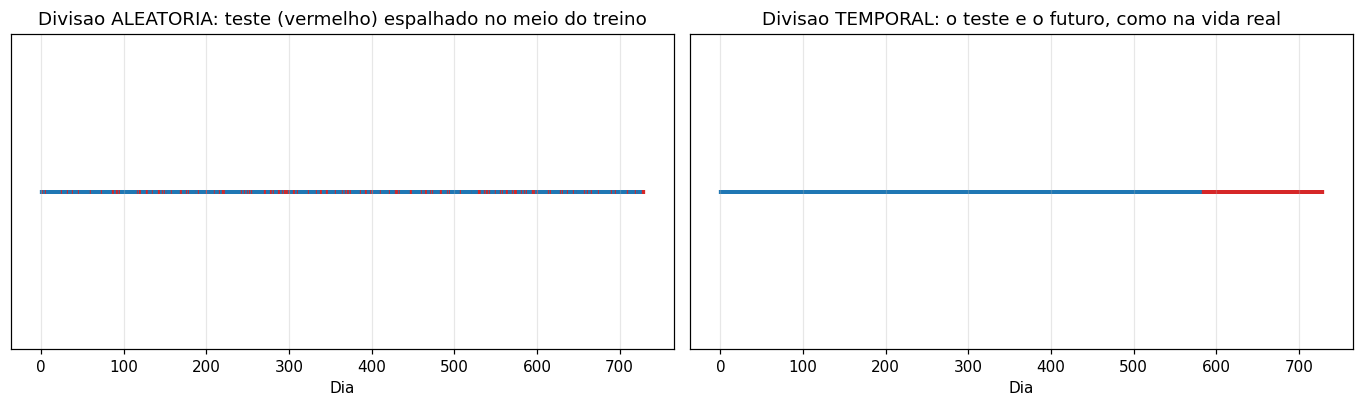

MAE com divisao ALEATORIA :  21.43 ligacoes  <- o numero que voce reportaria
MAE com divisao TEMPORAL  :  40.47 ligacoes  <- o numero que voce viveria

A divisao aleatoria fez o modelo parecer 47% melhor do que ele e.


In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# Duas colunas simples: posicao no tempo e dia da semana
X = np.column_stack([np.arange(n), serie.index.dayofweek])
y = serie.values

# (a) do jeito ERRADO: divisao aleatoria
X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(X, y, test_size=0.2, random_state=SEMENTE)
modelo_a = DecisionTreeRegressor(random_state=SEMENTE).fit(X_tr_a, y_tr_a)
mae_aleatorio = metricas(y_te_a, modelo_a.predict(X_te_a))[0]

# (b) do jeito CERTO: divisao cronologica
modelo_b = DecisionTreeRegressor(random_state=SEMENTE).fit(X[:corte], y[:corte])
mae_temporal = metricas(y[corte:], modelo_b.predict(X[corte:]))[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 3.8))
cores_a = np.array(["#1f77b4"] * n, dtype=object)
cores_a[X_te_a[:, 0]] = "#d62728"
ax1.scatter(np.arange(n), np.zeros(n), c=list(cores_a), s=6, marker="|")
ax1.set_title("Divisao ALEATORIA: teste (vermelho) espalhado no meio do treino")
ax1.set_yticks([]); ax1.set_xlabel("Dia")

cores_b = np.array(["#1f77b4"] * n, dtype=object)
cores_b[corte:] = "#d62728"
ax2.scatter(np.arange(n), np.zeros(n), c=list(cores_b), s=6, marker="|")
ax2.set_title("Divisao TEMPORAL: o teste e o futuro, como na vida real")
ax2.set_yticks([]); ax2.set_xlabel("Dia")
plt.tight_layout(); plt.show()

print(f"MAE com divisao ALEATORIA : {mae_aleatorio:6.2f} ligacoes  <- o numero que voce reportaria")
print(f"MAE com divisao TEMPORAL  : {mae_temporal:6.2f} ligacoes  <- o numero que voce viveria")
print(f"\nA divisao aleatoria fez o modelo parecer {100*(mae_temporal-mae_aleatorio)/mae_temporal:.0f}% melhor do que ele e.")

> **Lendo o resultado.** O mesmo modelo, os mesmos dados, duas formas de dividir:
>
> - Divisão **aleatória**: MAE de **21,4** ligações.
> - Divisão **temporal**: MAE de **40,5** ligações.
>
> A divisão aleatória fez o modelo parecer **47% melhor do que ele é**. Quem apresentasse o primeiro número estaria prometendo à operação uma precisão que o modelo não tem, e a diferença apareceria no primeiro mês de produção, quando já é tarde.
>
> Os dois gráficos explicam visualmente: à esquerda, os dias de teste em vermelho estão **espalhados no meio** dos dias de treino, sempre com vizinhos conhecidos ao lado. À direita, o teste é um bloco contínuo no fim, exatamente como o futuro se apresenta.
>
> A regra é curta: **em série temporal, a divisão é sempre cronológica**. Treino no passado, teste no futuro, e nunca o contrário. O mesmo vale para painéis, como vimos nos notebooks de carteiras e de autorização prévia: sortear linhas ali faria o modelo aprender o futuro de um contrato para prever o passado de outro.


### Walk-forward: um holdout só pode enganar

A separação cronológica resolve o vazamento, mas ainda deixa uma fragilidade: **o resultado depende do pedaço de tempo que você escolheu para testar**. Se aquele trimestre teve uma epidemia, uma greve ou uma mudança de processo, o número que você mediu não representa a operação normal.

A **validação walk-forward** (também chamada de origem móvel) resolve isso repetindo a avaliação várias vezes, deslizando a janela no tempo:

```
janela 1:  [========= treino =========][teste]
janela 2:  [============ treino ============][teste]
janela 3:  [=============== treino ===============][teste]
```

Cada janela treina com tudo o que existia até aquele momento e prevê o período seguinte, exatamente como o sistema faria mês a mês. No fim, você tem **vários** valores da métrica em vez de um, e a **dispersão entre eles** é uma informação tão valiosa quanto a média.


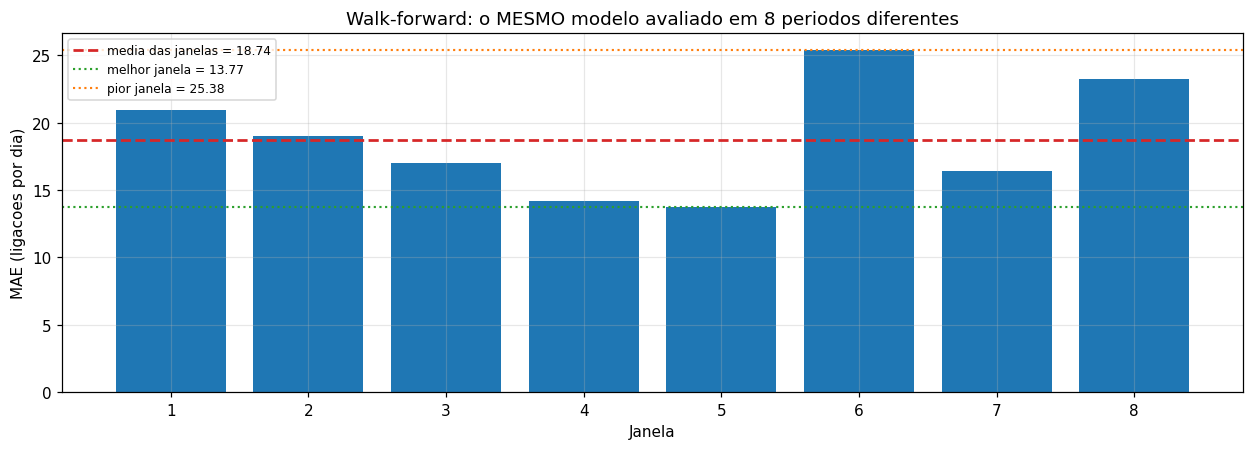

MAE medio das janelas : 18.74
Desvio-padrao entre elas: 4.18
Melhor janela: 13.77   |   Pior janela: 25.38   (diferenca de 84%)


,janela,treino ate,testa,MAE,MAPE (%)
0,1,03/02/2025,04/02 a 05/03,20.91,5.30
1,2,05/03/2025,06/03 a 04/04,19.04,4.18
2,3,04/04/2025,05/04 a 04/05,17.03,3.68
3,4,04/05/2025,05/05 a 03/06,14.21,3.24
4,5,03/06/2025,04/06 a 03/07,13.77,3.25
5,6,03/07/2025,04/07 a 02/08,25.38,5.47
6,7,02/08/2025,03/08 a 01/09,16.40,3.66
7,8,01/09/2025,02/09 a 01/10,23.22,5.11


In [10]:
def modelo_simples(historico, datas_futuras):
    """Nivel dos ultimos 28 dias multiplicado pelo perfil semanal historico."""
    perfil_hist = historico.groupby(historico.index.dayofweek).mean() / historico.mean()
    nivel = historico.iloc[-28:].mean()
    return np.array([nivel * perfil_hist.loc[d] for d in datas_futuras.dayofweek])


TAMANHO_JANELA = 30
resultados_wf = []
for k in range(8):
    fim_treino = 400 + k * 30
    historico = serie.iloc[:fim_treino]
    futuro = serie.iloc[fim_treino:fim_treino + TAMANHO_JANELA]
    if len(futuro) < TAMANHO_JANELA:
        break
    previsao = modelo_simples(historico, futuro.index)
    m, r, mp = metricas(futuro.values, previsao)
    resultados_wf.append({"janela": k + 1,
                          "treino ate": historico.index[-1].strftime("%d/%m/%Y"),
                          "testa": f"{futuro.index[0]:%d/%m} a {futuro.index[-1]:%d/%m}",
                          "MAE": round(m, 2), "MAPE (%)": round(mp, 2)})

wf = pd.DataFrame(resultados_wf)

fig, ax = plt.subplots(figsize=(11.5, 4.2))
ax.bar(wf.janela, wf.MAE, color="#1f77b4")
ax.axhline(wf.MAE.mean(), color="#d62728", ls="--", lw=1.8,
           label=f"media das janelas = {wf.MAE.mean():.2f}")
ax.axhline(wf.MAE.min(), color="#2ca02c", ls=":", lw=1.4, label=f"melhor janela = {wf.MAE.min():.2f}")
ax.axhline(wf.MAE.max(), color="#ff7f0e", ls=":", lw=1.4, label=f"pior janela = {wf.MAE.max():.2f}")
ax.set_title("Walk-forward: o MESMO modelo avaliado em 8 periodos diferentes")
ax.set_xlabel("Janela"); ax.set_ylabel("MAE (ligacoes por dia)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"MAE medio das janelas : {wf.MAE.mean():.2f}")
print(f"Desvio-padrao entre elas: {wf.MAE.std():.2f}")
print(f"Melhor janela: {wf.MAE.min():.2f}   |   Pior janela: {wf.MAE.max():.2f}   "
      f"(diferenca de {100*(wf.MAE.max()-wf.MAE.min())/wf.MAE.min():.0f}%)")
wf

> **Lendo o gráfico.** O **mesmo modelo**, avaliado em oito períodos consecutivos de 30 dias, produziu MAEs bem diferentes entre si. A média fica em **18,74**, mas a melhor janela marca **13,77** e a pior chega a **25,38**. Entre a melhor e a pior há uma diferença de **84%**.
>
> Pense no que isso significa. Se o seu relatório tivesse caído por acaso na melhor janela, você reportaria 13,8. Se tivesse caído na pior, reportaria 25,4. **O mesmo modelo, o mesmo código, e quase o dobro na conclusão.** Um único holdout não é um número, é um sorteio.
>
> Repare também na coluna do MAPE: ele varia de **3,24% a 5,47%** entre as janelas. Aquele patamar de 8% a 15% da literatura precisa ser lido com essa variabilidade em mente, porque um estudo que reporta um único período pode ter pegado a janela boa.
>
> O que fazer com isso, em três recomendações práticas:
>
> 1. **Reporte a média e a dispersão**, e não só a média. "MAE de 19, variando entre 13 e 26 conforme o período" é uma frase honesta que prepara a operação para a variabilidade que ela vai encontrar.
> 2. **Use walk-forward para comparar modelos.** Se o modelo A ganha do B em uma janela mas perde em cinco, a diferença era ruído. Comparar em uma única janela é como decidir um campeonato por um pênalti.
> 3. **Olhe a pior janela.** É ela que define o pior cenário que a escala precisa suportar, e geralmente ela tem uma explicação (um feriado prolongado, um surto), que é informação para o modelo seguinte.


## Quando faltar e sobrar custam diferente

Todas as métricas até aqui são **simétricas**: errar 10 para mais e errar 10 para menos contam exatamente o mesmo. Em quase nenhuma operação de saúde isso é verdade.

Faltar um atendente significa fila, tempo de espera, reclamação e, no pronto atendimento, risco assistencial. Sobrar um atendente significa uma hora paga sem produção. São dois custos reais e **de tamanhos bem diferentes**. Se o seu critério de escolha ignora essa diferença, você vai escolher o modelo que minimiza um erro que ninguém paga.

A saída é simples e não exige matemática nova: em vez de minimizar o erro, **minimize o custo**. Basta separar a parte do erro em que faltou da parte em que sobrou e dar pesos diferentes a cada uma:

$$ \text{Custo} = c*{\text{falta}} \cdot \overline{\max(y - \hat{y},\, 0)} \;+\; c*{\text{sobra}} \cdot \overline{\max(\hat{y} - y,\, 0)} $$

E, na prática, o ajuste que se faz sobre um modelo já treinado é acrescentar uma **margem de segurança** à previsão. A pergunta então vira: **de quanto deve ser a margem?** Vamos deixar o custo responder.


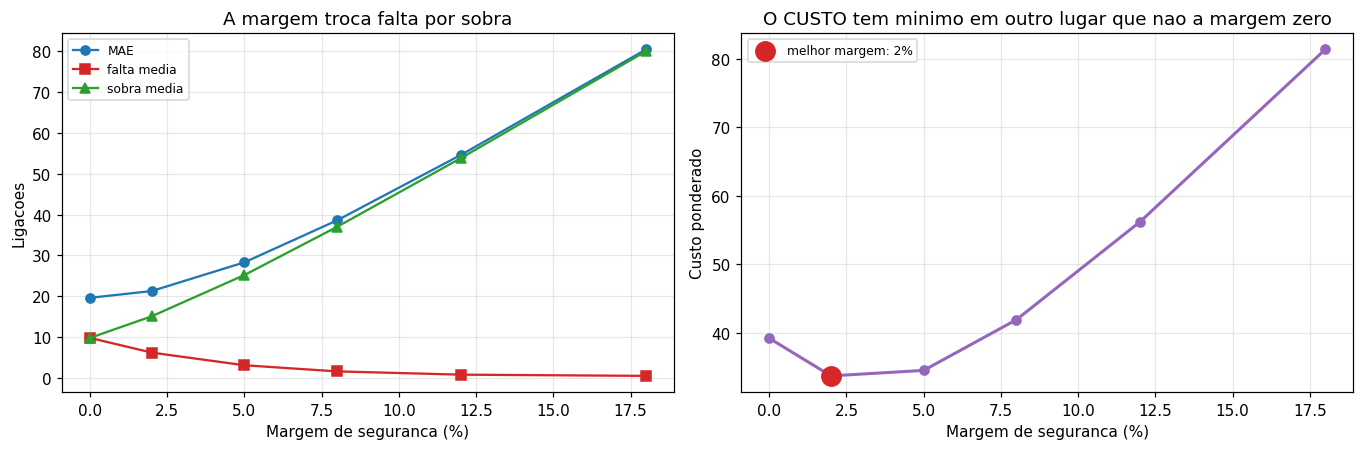

Melhor margem pelo MAE   : 0% (a previsao mais precisa)
Melhor margem pelo CUSTO : 2%  <- a decisao muda quando o custo e assimetrico


,margem de seguranca,MAE,RMSE,falta media,sobra media,CUSTO (3 x falta + 1 x sobra)
0,0%,19.62,27.32,9.8,9.8,39.2
1,2%,21.28,28.82,6.2,15.1,33.7
2,5%,28.31,35.52,3.1,25.2,34.5
3,8%,38.59,45.37,1.6,37.0,41.9
4,12%,54.58,60.73,0.8,53.8,56.2
5,18%,80.44,85.74,0.5,80.0,81.4


In [11]:
CUSTO_FALTA = 3.0     # faltar atendente custa 3x mais do que sobrar
CUSTO_SOBRA = 1.0

linhas = []
margens = [0.00, 0.02, 0.05, 0.08, 0.12, 0.18]
for margem in margens:
    p = prev_media4 * (1 + margem)
    falta = np.mean(np.maximum(teste.values - p, 0))     # previu MENOS do que aconteceu
    sobra = np.mean(np.maximum(p - teste.values, 0))     # previu MAIS do que aconteceu
    m, r, _ = metricas(teste.values, p)
    linhas.append({"margem de seguranca": f"{100*margem:.0f}%",
                   "MAE": round(m, 2), "RMSE": round(r, 2),
                   "falta media": round(falta, 1), "sobra media": round(sobra, 1),
                   "CUSTO (3 x falta + 1 x sobra)": round(CUSTO_FALTA * falta + CUSTO_SOBRA * sobra, 1)})
custos = pd.DataFrame(linhas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))
x = [100 * m for m in margens]
ax1.plot(x, custos.MAE, marker="o", color="#1f77b4", label="MAE")
ax1.plot(x, custos["falta media"], marker="s", color="#d62728", label="falta media")
ax1.plot(x, custos["sobra media"], marker="^", color="#2ca02c", label="sobra media")
ax1.set_title("A margem troca falta por sobra")
ax1.set_xlabel("Margem de seguranca (%)"); ax1.set_ylabel("Ligacoes"); ax1.legend(fontsize=8)

custo_valores = custos["CUSTO (3 x falta + 1 x sobra)"].values
melhor = int(np.argmin(custo_valores))
ax2.plot(x, custo_valores, marker="o", color="#9467bd", lw=2)
ax2.scatter([x[melhor]], [custo_valores[melhor]], s=160, color="#d62728", zorder=5,
            label=f"melhor margem: {x[melhor]:.0f}%")
ax2.set_title("O CUSTO tem minimo em outro lugar que nao a margem zero")
ax2.set_xlabel("Margem de seguranca (%)"); ax2.set_ylabel("Custo ponderado"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Melhor margem pelo MAE   : 0% (a previsao mais precisa)")
print(f"Melhor margem pelo CUSTO : {x[melhor]:.0f}%  <- a decisao muda quando o custo e assimetrico")
custos

> **Lendo o gráfico.** O painel da esquerda mostra o mecanismo: conforme a margem sobe, a **falta média** despenca (de 9,8 para menos de 1 ligação) e a **sobra média** cresce sem parar. O MAE, que soma as duas sem distinguir, só piora, e por isso ele elege a **margem zero**.
>
> O painel da direita conta outra história. Com o custo de faltar valendo três vezes o de sobrar, o custo total **cai** ao sair de margem zero, atinge o mínimo por volta de **2%** e depois volta a subir. Ou seja:
>
> - Pelo **MAE**, a melhor decisão é a previsão mais precisa possível, sem margem.
> - Pelo **custo real da operação**, a melhor decisão é prever um pouco a mais.
>
> Este é o fecho natural da aula, porque ele mostra que a métrica não é um detalhe técnico do fim do projeto: **ela é a tradução do custo do negócio para a linguagem do modelo**. Escolher MAE é afirmar que faltar e sobrar custam igual. Se isso não for verdade na sua operação, a métrica está mentindo por omissão.
>
> Dois avisos honestos. Primeiro, os pesos 3 e 1 são uma hipótese, e a conversa com a operação para estimá-los vale mais do que qualquer ajuste de hiperparâmetro. Segundo, existe uma forma mais elegante de fazer isso, que é treinar o modelo com uma **função de perda quantílica** (_pinball loss_), pedindo diretamente o percentil 70 ou 80 da demanda em vez da média. O ajuste por margem que fizemos aqui é a versão simples e transparente da mesma ideia.


## Laboratório interativo: sinta as métricas responderem

Mova os controles e observe as três métricas se moverem. O gráfico mostra os sete dias da nossa semana inicial, com o erro de um dia sob o seu controle.

O que experimentar:

- **Aumente o erro de um dia só** e compare o quanto o MAE sobe contra o quanto o RMSE sobe. A razão RMSE/MAE no título é o termômetro.
- **Reduza o nível da operação** e veja o MAPE disparar com os mesmos erros absolutos. É a demonstração de que erro percentual e erro absoluto contam histórias diferentes.
- **Deixe todos os erros iguais** (erro extra em zero) e confirme que MAE e RMSE ficam quase colados.


In [12]:
try:
    from ipywidgets import interact, IntSlider
    _INTERATIVO = True
except ImportError:
    _INTERATIVO = False


def laboratorio(erro_extra_no_dia_5=0, nivel_da_operacao=135):
    base = np.array([-5, 5, -3, 4, -5, 4, -3], dtype=float)
    erros = base.copy()
    erros[4] = erros[4] - erro_extra_no_dia_5
    reais = np.full(7, float(nivel_da_operacao))
    previstos = reais - erros

    m, r, mp = metricas(reais, previstos)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4))
    ax1.bar(dias, np.abs(erros), color=["#d62728" if i == 4 else "#1f77b4" for i in range(7)])
    ax1.set_title("Erro absoluto de cada dia"); ax1.set_ylabel("Erro (ligacoes)")
    ax1.tick_params(axis="x", rotation=25); ax1.set_ylim(0, 55)

    ax2.bar(["MAE", "RMSE"], [m, r], color=["#1f77b4", "#d62728"])
    for i, v in enumerate([m, r]):
        ax2.annotate(f"{v:.2f}", (i, v + 0.6), ha="center", fontsize=11)
    ax2.set_ylim(0, 30); ax2.set_title(f"MAPE = {mp:.2f}%   |   RMSE / MAE = {r/m:.2f}")

    plt.suptitle(f"Nivel da operacao: {nivel_da_operacao} ligacoes/dia   |   "
                 f"maior erro: {np.abs(erros).max():.0f}", y=1.02)
    plt.tight_layout(); plt.show()


if _INTERATIVO:
    interact(laboratorio,
             erro_extra_no_dia_5=IntSlider(value=0, min=0, max=45, step=5, description="erro extra"),
             nivel_da_operacao=IntSlider(value=135, min=20, max=400, step=5, description="nivel"))
else:
    print("ipywidgets indisponivel; exibindo tres cenarios estaticos.")
    laboratorio(0, 135)
    laboratorio(35, 135)
    laboratorio(0, 30)

interactive(children=(IntSlider(value=0, description='erro extra', max=45, step=5), IntSlider(value=135, descr…

> **O que observar.** Três descobertas que o laboratório entrega em segundos.
>
> **Com erro extra em zero**, MAE e RMSE ficam praticamente iguais (razão em torno de 1,02). Erros parecidos entre si não separam as duas métricas.
>
> **Ao subir o erro extra**, as duas barras crescem em ritmos completamente diferentes: o MAE sobe devagar, porque um dia entre sete pesa um sétimo; o RMSE dispara, porque o quadrado amplifica. A razão no título sobe junto e é o seu detector de dia ruim.
>
> **Ao baixar o nível da operação** sem mexer nos erros, MAE e RMSE **não se movem** (os erros absolutos são os mesmos) enquanto o **MAPE explode**. Errar 5 ligações em uma operação de 135 é 3,7%; errar as mesmas 5 em uma operação de 20 é 25%. Este é o experimento que explica, de uma vez por todas, por que um MAPE de 15% pode ser excelente em uma unidade pequena e inaceitável em uma grande.


## Síntese e checklist de avaliação

**As três métricas, em uma frase cada:**

| Métrica  | Fórmula resumida                  | A pergunta que ela responde                         |
| -------- | --------------------------------- | --------------------------------------------------- |
| **MAE**  | média de $\lvert erro \rvert$     | quanto eu erro em um dia típico?                    |
| **RMSE** | raiz da média de $erro^2$         | quão ruim é quando dá errado?                       |
| **MAPE** | média de $\lvert erro \rvert / y$ | quanto eu erro em proporção ao tamanho da operação? |

**O checklist, na ordem em que se usa:**

1. **Escolha a métrica antes de treinar**, conversando com quem sofre o erro. Métrica escolhida depois dos resultados vira justificativa.
2. **Reporte MAE e RMSE juntos.** A razão entre eles denuncia dias de desastre que a média esconde.
3. **Cuidado com o MAPE**: ele quebra com zeros e pune mais quem prevê a mais. Em série com valores pequenos, prefira **WMAPE**.
4. **Compare sempre com a regra boba.** O **MASE** responde em um número se o projeto compensa. Se ficar acima de 1, o modelo perdeu para "repita a semana passada".
5. **Nunca avalie no treino.** Erro de treino não é evidência de nada.
6. **Divida no tempo, nunca ao acaso.** Aqui a divisão aleatória fez o modelo parecer 47% melhor do que era.
7. **Use walk-forward.** Um holdout único variou de 13,8 a 25,4 no mesmo modelo. Reporte média e dispersão.
8. **Conheça o piso do problema.** Como vimos nos notebooks anteriores, boa parte da variação é ruído irredutível. Bater o piso é prova de vazamento, não de competência.
9. **Se faltar e sobrar custam diferente, minimize custo, não erro.** A decisão muda.
10. **Guarde a referência da literatura.** Para previsão de chegadas hospitalares, os estudos revisados na apostila relatam **MAPE entre 8% e 15%**. Um resultado muito melhor que isso, em dados reais, é motivo para procurar vazamento antes de comemorar.

**A frase para levar da aula:** a métrica não mede o modelo, ela mede **o que você decidiu que importa**. Escolher a métrica é a primeira decisão de modelagem, e é a única que, se estiver errada, torna todas as outras irrelevantes.

---

**Referências**

- Hyndman, R. J.; Koehler, A. B. (2006). Another look at measures of forecast accuracy. _International Journal of Forecasting_. (o artigo que propõe o MASE)
- Hyndman, R. J.; Athanasopoulos, G. (2021). _Forecasting: Principles and Practice_, 3ª edição, capítulo 5.
- Wargon, M. et al. (2009). A systematic review of models for forecasting the number of emergency department visits.
- Choudhury, A. (2019). Hourly forecasting of emergency department arrivals: time series analysis.
